In [195]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import imageio.v2 as imageio
import plotly.express as px

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import glob
from plotly.subplots import make_subplots
import plotly.graph_objects as go

import random
from sklearn.model_selection import train_test_split


import cv2
from matplotlib import pyplot as plt

import albumentations as A

import matplotlib.pyplot as plt
%matplotlib inline

# GLOBAL VARIABLES
SEED = 818
PATH_TRAINVAL = 'Dataset/Dataset/TrainVal/'
PATH_TEST = 'Dataset/Dataset/Test/'
TRAIN_SIZE = 0.8
BATCH_SIZE = 64
IMG_SIZE = 256

random.seed(SEED)

test_image_path = os.path.join(PATH_TEST, 'color/')
test_mask_path = os.path.join(PATH_TEST, 'label/')
test_image_list_orig = os.listdir(test_image_path)
test_mask_list_orig = os.listdir(test_mask_path)

trainval_image_path = os.path.join(PATH_TRAINVAL, 'color/')
trainval_mask_path = os.path.join(PATH_TRAINVAL, 'label/')
trainval_image_list_orig = os.listdir(trainval_image_path)
trainval_mask_list_orig = os.listdir(trainval_mask_path)
image_list = [trainval_image_path+i for i in trainval_image_list_orig]
mask_list = [trainval_mask_path+i for i in trainval_mask_list_orig]
len(trainval_mask_list_orig)

3680

# Image samples Visualization

In [230]:
def analyze(image, mask=None):
    """with plotly for detailed analysis"""
    if mask is None:
        fig = px.imshow(image)
        fig.show()
    fig = make_subplots(
    rows=1, cols=2)
    fig.add_trace(go.Image(z=image), 1, 1)
    fig.add_trace(go.Image(z=mask), 1, 2)
    fig.show()

def visualize(image, mask=None, masktitle='Mask'):
    plt.figure(figsize=(10, 5))
    
    if mask is None:
        plt.imshow(image)
        plt.axis('off')
        plt.show()
    else:
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title('Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        im = plt.imshow(mask, cmap='jet', vmin=0, vmax=3)  # Set fixed colorbar range
        plt.title(masktitle)
        plt.axis('off')

        # Add colorbar (acts as legend)
        cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
        cbar.set_label('Mask Intensity')

        plt.show()


N = 90

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

N = 190

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

Dataset/Dataset/TrainVal/color/Abyssinian_184.jpg 
 Dataset/Dataset/TrainVal/label/Abyssinian_184.png


Dataset/Dataset/TrainVal/color/american_bulldog_192.jpg 
 Dataset/Dataset/TrainVal/label/american_bulldog_192.png


# Image Input

In [118]:
test_paths_df = pd.DataFrame({"images":test_image_list_orig,"masks": test_mask_list_orig})
test_paths_df["path_images"] = test_image_path
test_paths_df["path_masks"] = test_mask_path
test_paths_df["path_images"] = test_paths_df["path_images"] + test_paths_df["images"]
test_paths_df["path_masks"] = test_paths_df["path_masks"] + test_paths_df["masks"]
test_paths_df.drop(columns=["images","masks"],inplace=True)
display(test_paths_df)

trainval_paths_df = pd.DataFrame({"images":trainval_image_list_orig,"masks": trainval_mask_list_orig})
trainval_paths_df["path_images"] = trainval_image_path
trainval_paths_df["path_masks"] = trainval_mask_path
trainval_paths_df["path_images"] = trainval_paths_df["path_images"] + trainval_paths_df["images"]
trainval_paths_df["path_masks"] = trainval_paths_df["path_masks"] + trainval_paths_df["masks"]
trainval_paths_df.drop(columns=["images","masks"],inplace=True)

train_paths_df, val_paths_df = train_test_split(trainval_paths_df, train_size=TRAIN_SIZE, random_state=SEED)
display(train_paths_df)
display(val_paths_df)


,path_images,path_masks
0,Dataset/Dataset/Test/color/Abyssinian_2.jpg,Dataset/Dataset/Test/label/Abyssinian_2.png
1,Dataset/Dataset/Test/color/Abyssinian_20.jpg,Dataset/Dataset/Test/label/Abyssinian_20.png
2,Dataset/Dataset/Test/color/Abyssinian_201.jpg,Dataset/Dataset/Test/label/Abyssinian_201.png
3,Dataset/Dataset/Test/color/Abyssinian_202.jpg,Dataset/Dataset/Test/label/Abyssinian_202.png
4,Dataset/Dataset/Test/color/Abyssinian_204.jpg,Dataset/Dataset/Test/label/Abyssinian_204.png
...,...,...
3705,Dataset/Dataset/Test/color/yorkshire_terrier_9...,Dataset/Dataset/Test/label/yorkshire_terrier_9...
3706,Dataset/Dataset/Test/color/yorkshire_terrier_9...,Dataset/Dataset/Test/label/yorkshire_terrier_9...
3707,Dataset/Dataset/Test/color/yorkshire_terrier_9...,Dataset/Dataset/Test/label/yorkshire_terrier_9...
3708,Dataset/Dataset/Test/color/yorkshire_terrier_9...,Dataset/Dataset/Test/label/yorkshire_terrier_9...


,path_images,path_masks
2713,Dataset/Dataset/TrainVal/color/Russian_Blue_13...,Dataset/Dataset/TrainVal/label/Russian_Blue_13...
344,Dataset/Dataset/TrainVal/color/basset_hound_14...,Dataset/Dataset/TrainVal/label/basset_hound_14...
573,Dataset/Dataset/TrainVal/color/Bengal_166.jpg,Dataset/Dataset/TrainVal/label/Bengal_166.png
2663,Dataset/Dataset/TrainVal/color/Ragdoll_184.jpg,Dataset/Dataset/TrainVal/label/Ragdoll_184.png
391,Dataset/Dataset/TrainVal/color/basset_hound_18...,Dataset/Dataset/TrainVal/label/basset_hound_18...
...,...,...
1141,Dataset/Dataset/TrainVal/color/Egyptian_Mau_14...,Dataset/Dataset/TrainVal/label/Egyptian_Mau_14...
2566,Dataset/Dataset/TrainVal/color/pug_179.jpg,Dataset/Dataset/TrainVal/label/pug_179.png
3493,Dataset/Dataset/TrainVal/color/wheaten_terrier...,Dataset/Dataset/TrainVal/label/wheaten_terrier...
2740,Dataset/Dataset/TrainVal/color/Russian_Blue_16...,Dataset/Dataset/TrainVal/label/Russian_Blue_16...


,path_images,path_masks
3178,Dataset/Dataset/TrainVal/color/shiba_inu_196.jpg,Dataset/Dataset/TrainVal/label/shiba_inu_196.png
1181,Dataset/Dataset/TrainVal/color/Egyptian_Mau_18...,Dataset/Dataset/TrainVal/label/Egyptian_Mau_18...
3284,Dataset/Dataset/TrainVal/color/Sphynx_105.jpg,Dataset/Dataset/TrainVal/label/Sphynx_105.png
3199,Dataset/Dataset/TrainVal/color/Siamese_122.jpg,Dataset/Dataset/TrainVal/label/Siamese_122.png
1804,Dataset/Dataset/TrainVal/color/keeshond_117.jpg,Dataset/Dataset/TrainVal/label/keeshond_117.png
...,...,...
895,Dataset/Dataset/TrainVal/color/boxer_190.jpg,Dataset/Dataset/TrainVal/label/boxer_190.png
469,Dataset/Dataset/TrainVal/color/beagle_166.jpg,Dataset/Dataset/TrainVal/label/beagle_166.png
3647,Dataset/Dataset/TrainVal/color/yorkshire_terri...,Dataset/Dataset/TrainVal/label/yorkshire_terri...
970,Dataset/Dataset/TrainVal/color/British_Shortha...,Dataset/Dataset/TrainVal/label/British_Shortha...


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from albumentations.pytorch import ToTensorV2

import cv2
import pandas as pd
from sklearn.model_selection import train_test_split


transform = A.Compose([
    A.Resize(256, 256),  # Resize to 256x256
    A.RandomCrop(width=240, height=240),
    # A.Rotate(limit=35, p=1.0), # Rotate image
    # A.HorizontalFlip(p=0.5), # Flip image horizontally
    A.RGBShift(r_shift_limit=25, g_shift_limit=25, b_shift_limit=25, p=0.5), # Shift RGB colors
    A.RandomBrightnessContrast(p=0.5), # Randomly change brightness and contrast
    # A.RandomGamma(p=0.5), # Randomly change image gamma
    # A.Blur(p=0.5), # Randomly blur image
    # A.GaussNoise(p=0.5), # Randomly add gaussian noise
    A.HorizontalFlip(p=0.5),
    ToTensorV2()
])

class SegmentationDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.color_map = {
            (128, 0, 0): 1,    # Cat
            (0, 128, 0): 2,    # Dog
            (0, 0, 0): 0,      # Background
            (255, 255, 255): 3 # Border
        }

        
    def __len__(self):
        return len(self.dataframe)
    
    def rgb_to_class(self, mask):
        """Convert an RGB mask to a single-channel class index mask."""
        h, w, _ = mask.shape
        class_mask = np.zeros((h, w), dtype=np.uint8)

        # Iterate over color map and assign class values
        for rgb, class_idx in self.color_map.items():
            mask_match = np.all(mask == np.array(rgb, dtype=np.uint8), axis=-1)
            class_mask[mask_match] = class_idx
        return class_mask
    

    def __getitem__(self, idx):
        image_path = self.dataframe.iloc[idx]["path_images"]
        mask_path = self.dataframe.iloc[idx]["path_masks"]

        image = cv2.imread(image_path, cv2.IMREAD_COLOR) # Image
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_COLOR) # Mask
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        # Convert RGB mask to class index mask
        mask = self.rgb_to_class(mask)


        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image, mask = transformed["image"], transformed["mask"]
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask


In [261]:
# Create dataset instances
train_dataset = SegmentationDataset(train_paths_df, transform=transform)
val_dataset = SegmentationDataset(val_paths_df, transform=transform)
test_dataset = SegmentationDataset(test_paths_df, transform=transform)

# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Example: Fetch a batch
images, masks = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}, Mask batch shape: {masks.shape}")


C:\Users\jorge\AppData\Local\Temp\ipykernel_22836\2488167453.py:66: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



Image batch shape: torch.Size([64, 3, 240, 240]), Mask batch shape: torch.Size([64, 240, 240])


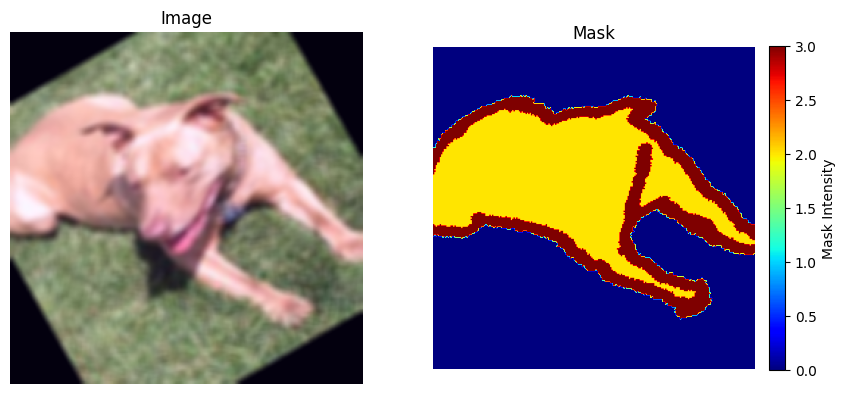

In [278]:
N=random.randint(0,BATCH_SIZE)
visualize(images[N].permute(1, 2, 0).numpy(),masks[N])

# 1  Dataset preprocessing and augmentation

### Testing

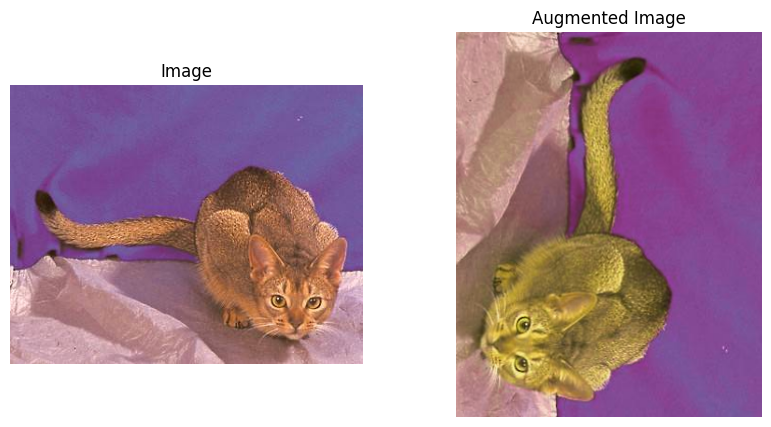

In [97]:
import random

import cv2
from matplotlib import pyplot as plt

import albumentations as A

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
transform = A.Compose([
        A.RandomRotate90(),
        A.HorizontalFlip(),
        A.VerticalFlip(),
        A.Transpose(),
        A.GaussNoise(),
        A.OneOf([
            A.MotionBlur(p=.2),
            A.MedianBlur(blur_limit=3, p=0.1),
            A.Blur(blur_limit=3, p=0.1),
        ], p=0.2),
        A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.2, rotate_limit=45, p=0.2),
        A.OneOf([
            A.OpticalDistortion(p=0.3),
            A.GridDistortion(p=.1),
        ], p=0.2),
        A.OneOf([
            A.CLAHE(clip_limit=2),
            A.RandomBrightnessContrast(),
        ], p=0.3),
        A.HueSaturationValue(p=0.3),
    ])
random.seed(4)
augmented_image = transform(image=image)['image']
visualize(image,augmented_image, 'Augmented Image')



### Implementation